In [ ]:
import tensorflow as tf
data_dir = "data_prepared"
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  # validation_split=0.2,
  subset="training",
  seed=123,
  # image_size=(img_height, img_width),
  batch_size=batch_size)

In [2]:
import tensorflow as tf
import os

DATA_DIR = "data_prepared"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(DATA_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

valid_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(DATA_DIR, "valid"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(DATA_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)


Found 8369 files belonging to 6 classes.
Found 1047 files belonging to 6 classes.
Found 1048 files belonging to 6 classes.
Classes: ['biodegradable', 'cardboard', 'glass', 'metal', 'paper', 'plastic']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
valid_ds = valid_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [3]:
from tensorflow.keras import layers
import numpy as np

normalization_layer = layers.Rescaling(1./255)

normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

0.0 0.9988797


In [4]:
valid_ds = valid_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

https://github.com/tensorflow/hub/issues/739

tf.keras.applications.mobilenet_v3.preprocess_input ===> The preprocessing logic has been included in the mobilenet_v3 model implementation. Users are no longer required to call this method to normalize the input data. This method does nothing and only kept as a placeholder to align the API surface between old and new version of model.

In [6]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
])
train_ds = normalized_ds.map(lambda x, y: (data_augmentation(x), y))

In [18]:
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras import models

base_model = MobileNetV3Small(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    include_preprocessing=False
)
base_model.trainable = False
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training = False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)

model = models.Model(inputs, outputs)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         3,462 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 942,582 (3.60 MB)

 Trainable params: 3,462 (13.52 KB)

 Non-trainable params: 939,120 (3.58 MB)

### Training with frozen base

In [19]:
# Trainable is false -> mobile net v3 layers are frozen, dense layer weights are not frozen - they keep updating and learning. Mobile net v3 already have good knowledge

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

metrics = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=10
)

Epoch 1/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 38s 139ms/step - accuracy: 0.6676 - loss: 0.9084 - val_accuracy: 0.8099 - val_loss: 0.5253
Epoch 2/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 35s 133ms/step - accuracy: 0.7834 - loss: 0.5968 - val_accuracy: 0.8453 - val_loss: 0.4396
Epoch 3/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 35s 133ms/step - accuracy: 0.8095 - loss: 0.5327 - val_accuracy: 0.8491 - val_loss: 0.4155
Epoch 4/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 35s 133ms/step - accuracy: 0.8214 - loss: 0.4971 - val_accuracy: 0.8558 - val_loss: 0.4009
Epoch 5/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 35s 135ms/step - accuracy: 0.8308 - loss: 0.4689 - val_accuracy: 0.8644 - val_loss: 0.3787
Epoch 6/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 35s 135ms/step - accuracy: 0.8341 - loss: 0.4618 - val_accuracy: 0.8682 - val_loss: 0.3673
Epoch 7/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 35s 134ms/step - accuracy: 0.8418 - loss: 0.4418 - val_accuracy: 0.8730 - val_loss: 0.3628
Epoch 8/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 35s 134ms/step - accuracy: 0.8462 - loss: 0

In [21]:
model.save('freezed_model.keras')

### Unfreezing and fine-tuning

In [22]:
base_model.trainable = True

# Freeze early layers, only train last 20
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Continue training
metrics_fine = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=10
)

Epoch 1/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 39s 138ms/step - accuracy: 0.8229 - loss: 0.5045 - val_accuracy: 0.8701 - val_loss: 0.3786
Epoch 2/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 36s 138ms/step - accuracy: 0.8557 - loss: 0.4061 - val_accuracy: 0.8825 - val_loss: 0.3486
Epoch 3/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 36s 137ms/step - accuracy: 0.8643 - loss: 0.3713 - val_accuracy: 0.8940 - val_loss: 0.3230
Epoch 4/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 36s 136ms/step - accuracy: 0.8785 - loss: 0.3341 - val_accuracy: 0.8988 - val_loss: 0.3117
Epoch 5/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 36s 139ms/step - accuracy: 0.8856 - loss: 0.3136 - val_accuracy: 0.9016 - val_loss: 0.2905
Epoch 6/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 36s 138ms/step - accuracy: 0.8931 - loss: 0.2910 - val_accuracy: 0.9064 - val_loss: 0.2832
Epoch 7/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 36s 137ms/step - accuracy: 0.9023 - loss: 0.2689 - val_accuracy: 0.9035 - val_loss: 0.2804
Epoch 8/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 36s 137ms/step - accuracy: 0.9111 - loss: 0

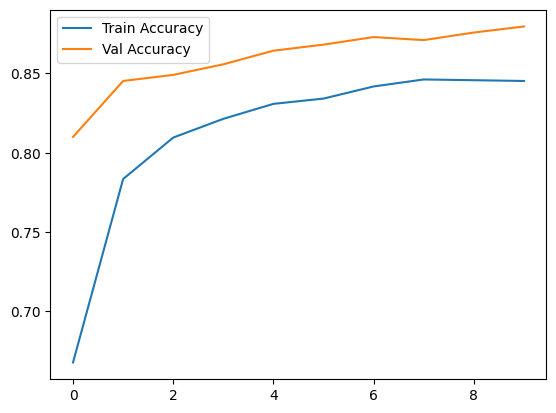

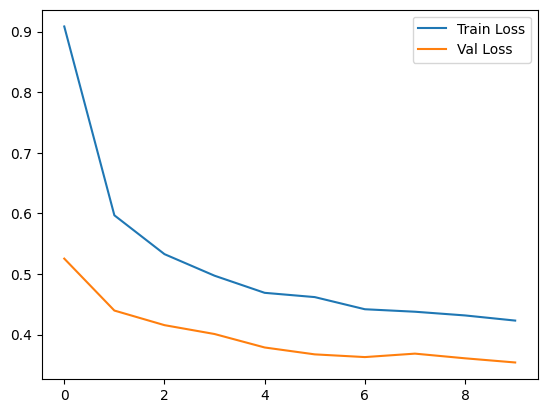

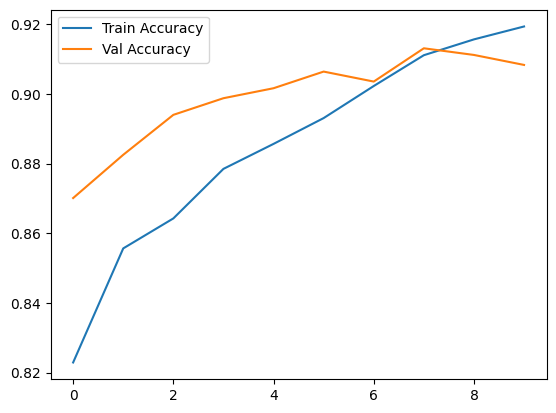

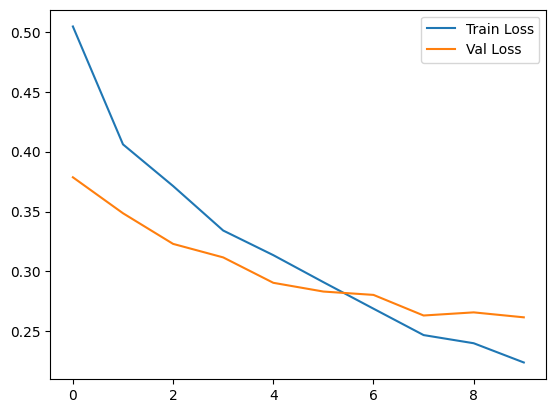

In [23]:
import matplotlib.pyplot as plt

plt.plot(metrics.history['accuracy'], label='Train Accuracy')
plt.plot(metrics.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.show()

plt.plot(metrics.history['loss'], label='Train Loss')
plt.plot(metrics.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()

plt.plot(metrics_fine.history['accuracy'], label='Train Accuracy')
plt.plot(metrics_fine.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.show()

plt.plot(metrics_fine.history['loss'], label='Train Loss')
plt.plot(metrics_fine.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()

In [32]:
model = tf.keras.models.load_model('freezed_model.keras')
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         3,462 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 946,046 (3.61 MB)

 Trainable params: 3,462 (13.52 KB)

 Non-trainable params: 939,120 (3.58 MB)

 Optimizer params: 3,464 (13.54 KB)

In [35]:
model = tf.keras.models.load_model('freezed_model.keras')

base_model = model.layers[1]  # MobileNetV3 is second layer ^

base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

metrics_fine2 = model.fit(train_ds, validation_data=valid_ds, epochs=5)

Epoch 1/5
262/262 ━━━━━━━━━━━━━━━━━━━━ 39s 139ms/step - accuracy: 0.8201 - loss: 0.5116 - val_accuracy: 0.8682 - val_loss: 0.3773
Epoch 2/5
262/262 ━━━━━━━━━━━━━━━━━━━━ 36s 137ms/step - accuracy: 0.8505 - loss: 0.4029 - val_accuracy: 0.8816 - val_loss: 0.3541
Epoch 3/5
262/262 ━━━━━━━━━━━━━━━━━━━━ 36s 138ms/step - accuracy: 0.8672 - loss: 0.3694 - val_accuracy: 0.8844 - val_loss: 0.3301
Epoch 4/5
262/262 ━━━━━━━━━━━━━━━━━━━━ 36s 137ms/step - accuracy: 0.8766 - loss: 0.3390 - val_accuracy: 0.8968 - val_loss: 0.3026
Epoch 5/5
262/262 ━━━━━━━━━━━━━━━━━━━━ 36s 138ms/step - accuracy: 0.8908 - loss: 0.3072 - val_accuracy: 0.8968 - val_loss: 0.2916


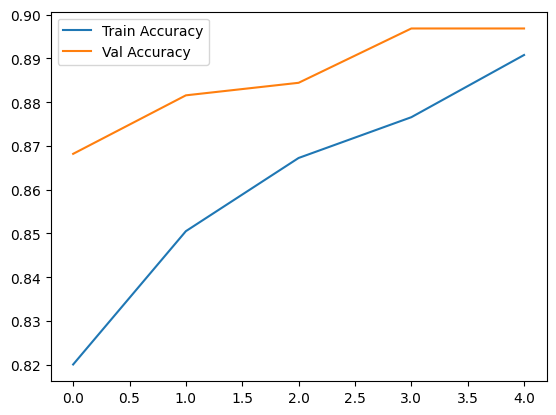

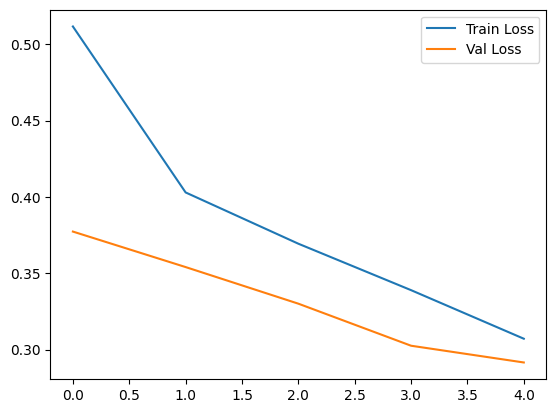

In [36]:
plt.plot(metrics_fine2.history['accuracy'], label='Train Accuracy')
plt.plot(metrics_fine2.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.show()

plt.plot(metrics_fine2.history['loss'], label='Train Loss')
plt.plot(metrics_fine2.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()

In [37]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8855 - loss: 0.3161

Test Accuracy: 0.8855
Test Loss: 0.3161


### Saving and converting to TFLite

In [43]:
model.save('waste_classifier_model.keras')

In [44]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('waste_classifier.tflite', 'wb') as f:
    f.write(tflite_model)


INFO:tensorflow:Assets written to: /tmp/tmp52497vj5/assets


INFO:tensorflow:Assets written to: /tmp/tmp52497vj5/assets


Saved artifact at '/tmp/tmp52497vj5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_6')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  137259856165008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137259856153872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137259856166160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137259856165392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137259856165584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137259856153296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137259856166736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137259856165968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137259856152912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137259856151760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1372593692672

W0000 00:00:1765035724.158668   17221 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1765035724.158687   17221 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2025-12-06 16:42:04.158823: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp52497vj5
2025-12-06 16:42:04.164107: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-12-06 16:42:04.164115: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp52497vj5
2025-12-06 16:42:04.221300: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-12-06 16:42:04.525592: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp52497vj5
2025-12-06 16:42:04.596446: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 437625 microseconds.
